# Анализ разводов в Мексике

## Описание проекта

### Цель исследования

Выявить типичные группы супружеских пар, завершивших брак разводом, на основе их социально-экономических и демографических характеристик.


### Задачи исследования

Для достижения поставленной цели необходимо решить следующие задачи:

1. **Первичный анализ и загрузка данных**
- Загрузка датасета
- Обзор структуры данных
- Первичные выводы
2. **Предобработка данных**
- Удаление неинформативных признаков
- Приведение типов данных и проверка корректности Age
- Формирование базовых признаков (feature engineering)
- Финальная очистка после генерации признаков
- Обработка пропусков
- Приведение типов данных
3. **Формирование информативных признаков**
- Преобразование индивидульных характеристик в парные
- Формирование итогового набора данных
4. **Разведочный анализ данных (EDA):**
- Анализ распределений ключевых признаков (возраст, доход, длительность брака, количество детей);
- Выявление выбросов и аномалий;
- Исследование зависимостей между признаками;
- Анализ категориальных признаков (например, распределение по гражданству).
5. **Кластеризация:**
- Выбор признаков для кластеризации;
- Масштабирование данных;
- K-Means;
- PCA-анализ структуры данных + K-Means;
- DBSCAN;
- PCA-анализ структуры данных + DBSCAN;
- PCA.
6. **Анализ результатов:**
- Вывод.

### Описание датасета

Используемый датасет содержит информацию примерно о 4000 супружеских парах, завершивших брак разводом в Мексике.

Датасет взят отсюда https://www.kaggle.com/code/kerneler/starter-divorce-marriage-dataset-with-3f6abe71-f/input?select=divorces_2000-2015_translated.csv

Каждое наблюдение соответствует одной супружеской паре и включает следующие группы признаков:

1. Информация о разводе:
- **Divorce_date** — дата развода
- **Type_of_divorce** — тип развода (например, по взаимному согласию / через суд)
2. Информация о муже
- **Nationality_partner_man** — гражданство мужчины
- **DOB_partner_man** — дата рождения мужчины
- **Place_of_birth_partner_man** — место рождения мужчины
- **Birth_municipality_of_partner_man** — муниципалитет рождения мужчины
- **Birth_federal_partner_man** — штат/регион рождения мужчины
- **Birth_country_partner_man** — страна рождения мужчины
- **Age_partner_man** — возраст мужчины
- **Residence_municipality_partner_man** — муниципалитет проживания мужчины
- **Residence_federal_partner_man** — регион проживания мужчины
- **Residence_country_partner_man** — страна проживания мужчины
- **Monthly_income_partner_man_peso** — доход мужчины (в песо)
- **Occupation_partner_man** — профессия мужчины
- **Place_of_residence_partner_man** — место проживания (более точное)
3. Информация о жене
- **Nationality_partner_woman** — гражданство женщины
- **DOB_partner_woman** — дата рождения женщины
- **DOB_registration_date_partner_woman** — дата регистрации рождения
- **Place_of_birth_partner_woman** — место рождения женщины
- **Birth_municipality_of_partner_woman** — муниципалитет рождения женщины
- **Birth_federal_partner_woman** — регион рождения женщины
- **Birth_country_partner_woman** — страна рождения женщины
- **Age_partner_woman** — возраст женщины
- **Place_of_residence_partner_woman** — место проживания
- **Residence_municipality_partner_woman** — муниципалитет проживания
- **Residence_federal_partner_woman** — регион проживания
- **Residence_country_partner_woman** — страна проживания
- **Occupation_partner_woman** — профессия женщины
- **Monthly_income_partner_woman_peso** — доход женщины
4. Смешанная информация
- **Date_of_marriage** — дата свадьбы
- **Marriage_certificate_place** — место регистрации брака
- **Marriage_certificate_municipality** — муниципалитет регистрации
- **Marriage_certificate_federal** — регион регистрации
- **Level_of_education_partner_man** — образование мужчины
- **Employment_status_partner_man** — занятость мужчины
- **Level_of_education_partner_woman** — образование женщины
- **Employment_status_partner_woman** — занятость женщины
- **Marriage_duration** — длительность брака (в годах)
- **Marriage_duration_months** — длительность в месяцах
- **Num_Children** — количество детей
- **Custody** — опека над детьми

## Ход исследования

### 1. Первичный анализ и загрузка данных

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# %matplotlib widget
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import DBSCAN

In [2]:
# Настройки отображения (чтобы красиво выводилось)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Загрузка датасета
df = pd.read_csv('dataset/divorces_2000-2015_translated.csv')

# Просмотр первых строк
print("\033[1mПервые 5 строк датасета:\033[0m")
display(df.head())

# Общая информация
print("\n\033[1mОбщая информация о датасете:\033[0m")
df.info()

# Размеры
print("\n\033[1mРазмер датасета (строки, столбцы):\033[0m")
print(df.shape)

# Информация о пропусках
print("\n\033[1mКоличество пропусков по столбцам:\033[0m")
missing = df.isnull().sum()
display(missing[missing > 0].sort_values(ascending=False))

print("\n\033[1mДоля пропусков (%):\033[0m")
missing_percent = (df.isnull().mean() * 100).round(2)
display(missing_percent[missing_percent > 0].sort_values(ascending=False))

# Описание числовых признаков
print("\nОписание числовых признаков:")
display(df.describe().round(2))

Первые 5 строк датасета:


,Divorce_date,Type_of_divorce,Nationality_partner_man,DOB_partner_man,Place_of_birth_partner_man,Birth_municipality_of_partner_man,Birth_federal_partner_man,Birth_country_partner_man,Age_partner_man,Residence_municipality_partner_man,Residence_federal_partner_man,Residence_country_partner_man,Monthly_income_partner_man_peso,Occupation_partner_man,Place_of_residence_partner_man,Nationality_partner_woman,DOB_partner_woman,DOB_registration_date_partner_woman,Place_of_birth_partner_woman,Birth_municipality_of_partner_woman,Birth_federal_partner_woman,Birth_country_partner_woman,Age_partner_woman,Place_of_residence_partner_woman,Residence_municipality_partner_woman,Residence_federal_partner_woman,Residence_country_partner_woman,Occupation_partner_woman,Monthly_income_partner_woman_peso,Date_of_marriage,Marriage_certificate_place,Marriage_certificate_municipality,Marriage_certificate_federal,Level_of_education_partner_man,Employment_status_partner_man,Level_of_education_partner_woman,Employment_status_partner_woman,Marriage_duration,Marriage_duration_months,Num_Children,Custody
0,9/6/06,Necesario,MEXICANA,18/12/75,XALAPA - ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,30.0,XALAPA,VERACRUZ,MEXICO,2000.0,PINTOR,XALAPA-ENRIQUEZ,MEXICANA,8/1/83,NaN,PUEBLA,PUEBLA,PUEBLA,MEXICO,22.0,XALAPA-ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,EMPLEADA,1800.0,26/6/00,XALAPA,XALAPA,VERACRUZ,SECUNDARIA,OBRERO,SECUNDARIA,EMPLEADO,5.0,NaN,1.0,NaN
1,1/2/00,Voluntario,MEXICANA,NaN,NaN,NaN,NaN,NaN,47.0,NaN,NaN,NaN,NaN,NaN,NaN,MEXICANA,NaN,NaN,NaN,NaN,NaN,NaN,41.0,NaN,NaN,NaN,NaN,NaN,NaN,17/2/77,XALAPA,XALAPA,VERACRUZ,PREPARATORIA,ESTABLECIMIENTO,PREPARATORIA,EMPLEADO,NaN,NaN,NaN,NaN
2,1/2/05,Necesario,MEXICANA,22/2/55,XALAPA - ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,49.0,NaN,NaN,NaN,NaN,MEDICO,NaN,MEXICANA,21/3/47,NaN,XALAPA-ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,57.0,XALAPA-ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,JUBILADA,NaN,18/12/75,XALAPA,XALAPA,VERACRUZ,PREPARATORIA,OBRERO,NaN,TRABAJADOR POR CUENTA PROPIA EN VIA PUBLICA,NaN,NaN,NaN,NaN
3,1/2/06,Necesario,MEXICANA,20/1/64,XALAPA - ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,42.0,XALAPA,VERACRUZ,MEXICO,6000.0,EMPLEADO,XALAPA-ENRIQUEZ,MEXICANA,NaN,NaN,XALAPA-ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,NaN,XALAPA-ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,COMERCIANTE,5000.0,3/12/87,XALAPA,XALAPA,VERACRUZ,PROFESIONAL,EMPLEADO,PREPARATORIA,EMPLEADO,18.0,NaN,2.0,MADRE
4,1/2/06,Necesario,MEXICANA,30/10/75,XALAPA - ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,30.0,COATEPEC,VERACRUZ,MEXICO,18000.0,MEDICO,COATEPEC,MEXICANA,13/10/78,NaN,XALAPA-ENRIQUEZ,XALAPA,VERACRUZ,MEXICO,27.0,COATEPEC,COATEPEC,VERACRUZ,MEXICO,AMA DE CASA,NaN,14/11/98,XALAPA,XALAPA,VERACRUZ,PROFESIONAL,EMPLEADO,PREPARATORIA,NO TRABAJA,7.0,NaN,2.0,MADRE



Общая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4923 entries, 0 to 4922
Data columns (total 41 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Divorce_date                          4923 non-null   object 
 1   Type_of_divorce                       4923 non-null   object 
 2   Nationality_partner_man               4922 non-null   object 
 3   DOB_partner_man                       4542 non-null   object 
 4   Place_of_birth_partner_man            4797 non-null   object 
 5   Birth_municipality_of_partner_man     4794 non-null   object 
 6   Birth_federal_partner_man             4795 non-null   object 
 7   Birth_country_partner_man             4796 non-null   object 
 8   Age_partner_man                       4816 non-null   float64
 9   Residence_municipality_partner_man    4599 non-null   object 
 10  Residence_federal_partner_man         4600 non-null   

Marriage_duration_months                3368
Custody                                 2851
DOB_registration_date_partner_woman     2679
Monthly_income_partner_woman_peso       2119
Num_Children                            1912
Monthly_income_partner_man_peso         1419
Occupation_partner_woman                 578
Occupation_partner_man                   529
DOB_partner_woman                        452
Employment_status_partner_woman          417
DOB_partner_man                          381
Level_of_education_partner_woman         380
Employment_status_partner_man            356
Residence_country_partner_man            324
Residence_municipality_partner_man       324
Residence_federal_partner_man            323
Place_of_residence_partner_man           321
Place_of_residence_partner_woman         307
Residence_municipality_partner_woman     307
Residence_federal_partner_woman          305
Residence_country_partner_woman          305
Level_of_education_partner_man           304
Marriage_d


Доля пропусков (%):


Marriage_duration_months                68.41
Custody                                 57.91
DOB_registration_date_partner_woman     54.42
Monthly_income_partner_woman_peso       43.04
Num_Children                            38.84
Monthly_income_partner_man_peso         28.82
Occupation_partner_woman                11.74
Occupation_partner_man                  10.75
DOB_partner_woman                        9.18
Employment_status_partner_woman          8.47
DOB_partner_man                          7.74
Level_of_education_partner_woman         7.72
Employment_status_partner_man            7.23
Residence_country_partner_man            6.58
Residence_municipality_partner_man       6.58
Residence_federal_partner_man            6.56
Place_of_residence_partner_man           6.52
Place_of_residence_partner_woman         6.24
Residence_municipality_partner_woman     6.24
Residence_federal_partner_woman          6.20
Residence_country_partner_woman          6.20
Level_of_education_partner_man    


Описание числовых признаков:


,Age_partner_man,Monthly_income_partner_man_peso,Age_partner_woman,Monthly_income_partner_woman_peso,Marriage_duration,Marriage_duration_months,Num_Children
count,4816.00,3504.00,4772.00,2804.00,4688.00,1555.00,3011.00
mean,39.44,10920.11,36.96,7374.25,11.72,6.29,1.82
std,10.40,70569.76,9.93,16337.05,9.30,3.87,0.93
min,19.00,2.40,17.00,3.50,1.00,0.00,1.00
25%,32.00,3000.00,29.00,3000.00,4.00,4.00,1.00
50%,38.00,5600.00,35.00,5000.00,9.00,6.00,2.00
75%,46.00,10000.00,43.00,8000.00,17.00,9.00,2.00
max,91.00,3150242.00,84.00,708652.00,61.00,93.00,10.00


### 2. Предобработка данных

#### 2.1 Удаление неинформативных признаков

In [3]:
# Текущие имена столбцов
print(df.columns)

Index(['Divorce_date', 'Type_of_divorce', 'Nationality_partner_man', 'DOB_partner_man', 'Place_of_birth_partner_man', 'Birth_municipality_of_partner_man', 'Birth_federal_partner_man', 'Birth_country_partner_man', 'Age_partner_man', 'Residence_municipality_partner_man', 'Residence_federal_partner_man', 'Residence_country_partner_man', 'Monthly_income_partner_man_peso', 'Occupation_partner_man', 'Place_of_residence_partner_man', 'Nationality_partner_woman', 'DOB_partner_woman', 'DOB_registration_date_partner_woman', 'Place_of_birth_partner_woman', 'Birth_municipality_of_partner_woman', 'Birth_federal_partner_woman', 'Birth_country_partner_woman', 'Age_partner_woman', 'Place_of_residence_partner_woman', 'Residence_municipality_partner_woman', 'Residence_federal_partner_woman', 'Residence_country_partner_woman', 'Occupation_partner_woman', 'Monthly_income_partner_woman_peso', 'Date_of_marriage', 'Marriage_certificate_place', 'Marriage_certificate_municipality',
       'Marriage_certificate

In [4]:
# Список столбцов для удаления (на текущем этапе)
columns_to_drop = [
    # Дата регистрации (бесполезный признак из-за пропусков в 54%)
    'DOB_registration_date_partner_woman',

    # География рождения (слишком детализировано)
    'Place_of_birth_partner_man',
    'Birth_municipality_of_partner_man',
    'Birth_federal_partner_man',
    'Birth_country_partner_man',
    'Place_of_birth_partner_woman',
    'Birth_municipality_of_partner_woman',
    'Birth_federal_partner_woman',
    'Birth_country_partner_woman',

    # География проживания
    'Residence_municipality_partner_man',
    'Residence_federal_partner_man',
    'Residence_country_partner_man',
    'Place_of_residence_partner_man',
    'Place_of_residence_partner_woman',
    'Residence_municipality_partner_woman',
    'Residence_federal_partner_woman',
    'Residence_country_partner_woman',

    # Дублирующая/слабая информация
    'Marriage_duration_months',  # много пропусков
    'Custody',                   # много пропусков

    # Место регистрации брака
    'Marriage_certificate_place',
    'Marriage_certificate_municipality',
    'Marriage_certificate_federal'
]

# Удаление столбцов
df = df.drop(columns=columns_to_drop)

# Проверка результата
print("Оставшиеся столбцы:")
print(df.columns.tolist())

Оставшиеся столбцы:
['Divorce_date', 'Type_of_divorce', 'Nationality_partner_man', 'DOB_partner_man', 'Age_partner_man', 'Monthly_income_partner_man_peso', 'Occupation_partner_man', 'Nationality_partner_woman', 'DOB_partner_woman', 'Age_partner_woman', 'Occupation_partner_woman', 'Monthly_income_partner_woman_peso', 'Date_of_marriage', 'Level_of_education_partner_man', 'Employment_status_partner_man', 'Level_of_education_partner_woman', 'Employment_status_partner_woman', 'Marriage_duration', 'Num_Children']


#### 2.2 Приведение типов данных и проверка корректности Age

##### 1. Перевод дат в формат datetime

In [5]:
# Парсер дат
def parse_custom_date(date_str):
    if pd.isna(date_str):
        return pd.NaT
    
    try:
        day, month, year = date_str.split('/')
        day = int(day)
        month = int(month)
        year = int(year)
        
        # 2-значный год → 1900 или 2000
        if 16 <= year <= 99:
            year += 1900
        else:
            year += 2000
        
        return pd.Timestamp(year=year, month=month, day=day)
    
    except:
        return pd.NaT

# Столбцы которые парсим
date_columns = [
    'Divorce_date',
    'Date_of_marriage',
    'DOB_partner_man',
    'DOB_partner_woman'
]

for col in date_columns:
    df[col] = df[col].apply(parse_custom_date)

# Проверка
print("Проверка дат:")
display(df[date_columns].head())

Проверка дат:


,Divorce_date,Date_of_marriage,DOB_partner_man,DOB_partner_woman
0,2006-06-09,2000-06-26,1975-12-18,1983-01-08
1,2000-02-01,1977-02-17,NaT,NaT
2,2005-02-01,1975-12-18,1955-02-22,1947-03-21
3,2006-02-01,1987-12-03,1964-01-20,NaT
4,2006-02-01,1998-11-14,1975-10-30,1978-10-13


##### 2. Проверка корректности Age


Средняя ошибка:
Мужчины: 0.54
Женщины: 0.54

Доля корректных (±1 год):
Мужчины: 96.43%
Женщины: 96.64%

Выбросы (>1 год):
Мужчины: 156
Женщины: 146

Из них 1–2 года:
Мужчины: 153
Женщины: 143

Сильные выбросы (>2 года):
Мужчины: 3
Женщины: 3


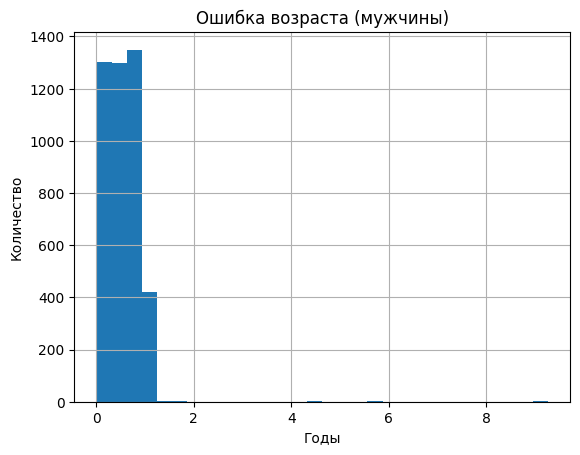

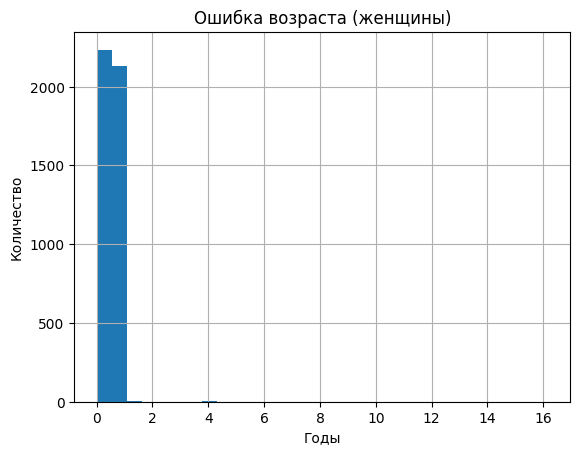

Удаляем наблюдений: 6


In [6]:
# Убираем строки с пропущенными датами
df_age = df.dropna(subset=['Divorce_date', 'DOB_partner_man', 'DOB_partner_woman']).copy()

df_age['calc_age_man'] = (df_age['Divorce_date'] - df_age['DOB_partner_man']).dt.days / 365
df_age['calc_age_woman'] = (df_age['Divorce_date'] - df_age['DOB_partner_woman']).dt.days / 365

df_age['age_error_man'] = df_age['Age_partner_man'] - df_age['calc_age_man']
df_age['age_error_woman'] = df_age['Age_partner_woman'] - df_age['calc_age_woman']

df_age['abs_error_man'] = df_age['age_error_man'].abs()
df_age['abs_error_woman'] = df_age['age_error_woman'].abs()


# Анализ
print("\nСредняя ошибка:")
print("Мужчины:", round(df_age['abs_error_man'].mean(), 2))
print("Женщины:", round(df_age['abs_error_woman'].mean(), 2))

valid_man = (df_age['abs_error_man'] <= 1).mean() * 100
valid_woman = (df_age['abs_error_woman'] <= 1).mean() * 100

print("\nДоля корректных (±1 год):")
print(f"Мужчины: {valid_man:.2f}%")
print(f"Женщины: {valid_woman:.2f}%")

# Выбросы > 1 года
outliers_man = (df_age['abs_error_man'] > 1).sum()
outliers_woman = (df_age['abs_error_woman'] > 1).sum()

# 1–2 года
mid_outliers_man = ((df_age['abs_error_man'] > 1) & (df_age['abs_error_man'] <= 2)).sum()
mid_outliers_woman = ((df_age['abs_error_woman'] > 1) & (df_age['abs_error_woman'] <= 2)).sum()

# >2 года
strong_outliers_man = (df_age['abs_error_man'] > 2).sum()
strong_outliers_woman = (df_age['abs_error_woman'] > 2).sum()

print("\nВыбросы (>1 год):")
print("Мужчины:", outliers_man)
print("Женщины:", outliers_woman)

print("\nИз них 1–2 года:")
print("Мужчины:", mid_outliers_man)
print("Женщины:", mid_outliers_woman)

print("\nСильные выбросы (>2 года):")
print("Мужчины:", strong_outliers_man)
print("Женщины:", strong_outliers_woman)


# Графики
plt.figure()
df_age['abs_error_man'].hist(bins=30)
plt.title("Ошибка возраста (мужчины)")
plt.xlabel("Годы")
plt.ylabel("Количество")
plt.show()

plt.figure()
df_age['abs_error_woman'].hist(bins=30)
plt.title("Ошибка возраста (женщины)")
plt.xlabel("Годы")
plt.ylabel("Количество")
plt.show()


# Удаление аномалий (>2 лет)
# маска внутри df_age
mask_bad_age = (df_age['abs_error_man'] > 2) | (df_age['abs_error_woman'] > 2)

print("Удаляем наблюдений:", mask_bad_age.sum())

# получаем индексы плохих строк
bad_indices = df_age[mask_bad_age].index

# удаляем их из основного df
df = df.drop(index=bad_indices).copy()

##### Вывод

Проверка признака Age показала высокую согласованность с возрастом, вычисленным на основе дат рождения и даты развода. Средняя ошибка составляет около 0.54 года, а более 96% наблюдений укладываются в допустимую погрешность ±1 год.

Таким образом, можно сделать вывод, что признак Age фактически отражает возраст на момент развода и является корректным и надёжным для дальнейшего анализа и кластеризации данных. Существенных аномалий в признаке не выявлено.

Для проверки корректности возраста использовалась подвыборка данных без пропусков в датах. На её основе были выявлены 6 наблюдений с ошибкой более 2 лет, которые были удалены как некорректные.

#### 2.3 Формирование базовых признаков (feature engineering)

In [7]:
# -------------------------------
# 1. Длительность брака (в годах)
# -------------------------------
# пересчитываем как разницу дат развода и заключения брака

df['Marriage_duration_calc'] = (
    df['Divorce_date'] - df['Date_of_marriage']
).dt.days / 365

# -------------------------------
# 2. Возраст на момент брака (через DOB)
# -------------------------------
df['age_at_marriage_man'] = (
    df['Date_of_marriage'] - df['DOB_partner_man']
).dt.days / 365

df['age_at_marriage_woman'] = (
    df['Date_of_marriage'] - df['DOB_partner_woman']
).dt.days / 365


# -------------------------------
# 3. Восстановление пропусков в возрасте на момент брака
# -------------------------------
# идея:
# если возраст на момент брака не считается → используем:
# Age (на момент развода) - длительность брака

df['age_at_marriage_man'] = df['age_at_marriage_man'].fillna(
    df['Age_partner_man'] - df['Marriage_duration_calc']
)

df['age_at_marriage_woman'] = df['age_at_marriage_woman'].fillna(
    df['Age_partner_woman'] - df['Marriage_duration_calc']
)

# -------------------------------
# 4. Проверка результата
# -------------------------------
print("Проверка новых признаков:\n")

print("Длительность брака (новая):")
print(df['Marriage_duration_calc'].describe())

print("\nВозраст на момент брака (мужчины):")
print(df['age_at_marriage_man'].describe())

print("\nВозраст на момент брака (женщины):")
print(df['age_at_marriage_woman'].describe())

# Аномалии (<15 лет)
mask_bad_marriage_age = (
    (df['age_at_marriage_man'] < 15) |
    (df['age_at_marriage_woman'] < 15)
)

num_bad = mask_bad_marriage_age.sum()

print("\nЧисло аномальных значений (<15 лет на момент брака):", num_bad)
print(f"Доля аномалий: {num_bad / len(df):.2%}")

# -------------------------------
# 5. Сравнение со старым признаком
# -------------------------------
if 'Marriage_duration' in df.columns:
    
    # берём только строки, где есть оба значения
    mask_valid = df['Marriage_duration'].notna() & df['Marriage_duration_calc'].notna()
    
    diff = (
        df.loc[mask_valid, 'Marriage_duration'] -
        df.loc[mask_valid, 'Marriage_duration_calc']
    ).abs()
    
    print("\nСредняя разница с исходным Marriage_duration:", round(diff.mean(), 3))
    print("Количество использованных наблюдений:", mask_valid.sum())

# -------------------------------
# 6. Удаление аномалий возраста на момент брака
# -------------------------------

print("\nУдаляем наблюдений (возраст < 15):", num_bad)

df = df.loc[~mask_bad_marriage_age].copy()

Проверка новых признаков:

Длительность брака (новая):
count    4917.000000
mean       12.872687
std         9.573335
min         0.753425
25%         5.380822
50%        10.473973
75%        18.057534
max        69.394521
Name: Marriage_duration_calc, dtype: float64

Возраст на момент брака (мужчины):
count    4810.000000
mean       27.183272
std         6.948247
min       -11.764384
25%        22.605479
50%        25.917808
75%        29.897945
max        73.021918
Name: age_at_marriage_man, dtype: float64

Возраст на момент брака (женщины):
count    4769.000000
mean       24.795162
std         6.295636
min       -29.235616
25%        20.709589
50%        23.824658
75%        27.550685
max        61.767123
Name: age_at_marriage_woman, dtype: float64

Число аномальных значений (<15 лет на момент брака): 54
Доля аномалий: 1.10%

Средняя разница с исходным Marriage_duration: 1.468
Количество использованных наблюдений: 4682

Удаляем наблюдений (возраст < 15): 54


##### Вывод:
В ходе формирования новых признаков была пересчитана длительность брака и возраст партнёров на момент вступления в брак. Полученные значения в целом выглядят реалистично и согласуются с исходными данными (средняя разница с исходной длительностью брака составляет около 1.47 года).

Однако были выявлены аномальные наблюдения, в которых возраст на момент брака оказался меньше 15 лет. Такие значения противоречат здравому смыслу и, вероятно, связаны с ошибками в данных. Всего обнаружено 54 таких случая (~1.1% выборки).

Данные наблюдения были удалены, так как они не являются репрезентативными и могут негативно повлиять на дальнейший анализ.

#### 2.4 Финальная очистка после генерации признаков

In [8]:
# Удаляем исходные даты, так как вся информация уже извлечена
columns_to_drop = [
    'Age_partner_man',
    'Age_partner_woman',
    'Divorce_date',
    'Date_of_marriage',
    'DOB_partner_man',
    'DOB_partner_woman',
    'Marriage_duration'  # старый признак
]

# удаление только тех колонок, которые реально существуют
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])


# Перестановка столбцов (для удобства анализа)
new_order = [
    'Type_of_divorce',
    
    'Nationality_partner_man',
    'age_at_marriage_man',
    'Monthly_income_partner_man_peso',
    'Occupation_partner_man',
    
    'Nationality_partner_woman',
    'age_at_marriage_woman',
    'Monthly_income_partner_woman_peso',
    'Occupation_partner_woman',
    
    'Level_of_education_partner_man',
    'Employment_status_partner_man',
    
    'Level_of_education_partner_woman',
    'Employment_status_partner_woman',
    
    'Marriage_duration_calc',
    'Num_Children'
]

# применяем порядок
df = df[new_order]

# проверка
display(df.head())
print("\nРазмер датасета:", df.shape)

,Type_of_divorce,Nationality_partner_man,age_at_marriage_man,Monthly_income_partner_man_peso,Occupation_partner_man,Nationality_partner_woman,age_at_marriage_woman,Monthly_income_partner_woman_peso,Occupation_partner_woman,Level_of_education_partner_man,Employment_status_partner_man,Level_of_education_partner_woman,Employment_status_partner_woman,Marriage_duration_calc,Num_Children
0,Necesario,MEXICANA,24.539726,2000.0,PINTOR,MEXICANA,17.476712,1800.0,EMPLEADA,SECUNDARIA,OBRERO,SECUNDARIA,EMPLEADO,5.956164,1.0
1,Voluntario,MEXICANA,24.030137,NaN,NaN,MEXICANA,18.030137,NaN,NaN,PREPARATORIA,ESTABLECIMIENTO,PREPARATORIA,EMPLEADO,22.969863,NaN
2,Necesario,MEXICANA,20.832877,NaN,MEDICO,MEXICANA,28.764384,NaN,JUBILADA,PREPARATORIA,OBRERO,NaN,TRABAJADOR POR CUENTA PROPIA EN VIA PUBLICA,29.145205,NaN
3,Necesario,MEXICANA,23.884932,6000.0,EMPLEADO,MEXICANA,NaN,5000.0,COMERCIANTE,PROFESIONAL,EMPLEADO,PREPARATORIA,EMPLEADO,18.178082,2.0
4,Necesario,MEXICANA,23.057534,18000.0,MEDICO,MEXICANA,20.101370,NaN,AMA DE CASA,PROFESIONAL,EMPLEADO,PREPARATORIA,NO TRABAJA,7.221918,2.0



Размер датасета: (4863, 15)


##### 2.5 Обработка пропусков

In [9]:
# ================================
# Процент пропусков по столбцам
# ================================

missing_percent = ((df.isna().mean() * 100).round(2)).sort_values(ascending=False)

print("Процент пропусков по столбцам:\n")
print(missing_percent[missing_percent > 0])

Процент пропусков по столбцам:

Monthly_income_partner_woman_peso    42.75
Num_Children                         38.93
Monthly_income_partner_man_peso      28.81
Occupation_partner_woman             11.70
Occupation_partner_man               10.73
Employment_status_partner_woman       8.43
Level_of_education_partner_woman      7.65
Employment_status_partner_man         7.22
Level_of_education_partner_man        6.17
age_at_marriage_woman                 3.04
age_at_marriage_man                   2.16
Nationality_partner_woman             0.06
Nationality_partner_man               0.02
dtype: float64


In [10]:
# ================================
# Числовые признаки — медиана + индикатор пропуска
# ================================

num_cols_median = [
    'Monthly_income_partner_man_peso',
    'Monthly_income_partner_woman_peso',
    'Num_Children',
    'age_at_marriage_man',
    'age_at_marriage_woman'
]

for col in num_cols_median:
    # индикатор пропуска
    df[col + '_missing'] = df[col].isna().astype(int)
    
    # медианная замена
    df[col] = df[col].fillna(df[col].median())


# ================================
# Категориальные признаки — "Unknown"
# ================================

cat_cols_unknown = [
    'Occupation_partner_man',
    'Occupation_partner_woman',
    'Employment_status_partner_man',
    'Employment_status_partner_woman',
    'Level_of_education_partner_man',
    'Level_of_education_partner_woman',
    'Nationality_partner_man',
    'Nationality_partner_woman'
]

for col in cat_cols_unknown:
    df[col] = df[col].fillna('Unknown')


# ================================
# Проверка результата
# ================================

print("Пропуски после обработки:\n")
print(df.isna().sum()[df.isna().sum() > 0])

Пропуски после обработки:

Series([], dtype: int64)


##### 2.6 Приведение типов данных

In [11]:
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].astype("string")

print(df.select_dtypes(include='object').columns)

Index([], dtype='object')


### 3. Формирование информативных признаков

#### 3.1 Преобразование индивидульных характеристик в парные

In [12]:
# разница в возрасте
df['age_diff'] = df['age_at_marriage_man'] - df['age_at_marriage_woman']

# средний возраст пары
df['age_mean'] = (df['age_at_marriage_man'] + df['age_at_marriage_woman']) / 2

# разница в доходах
df['income_diff'] = (
    df['Monthly_income_partner_man_peso'] -
    df['Monthly_income_partner_woman_peso']
)

# средний доход пары
df['income_mean'] = (
    df['Monthly_income_partner_man_peso'] +
    df['Monthly_income_partner_woman_peso']
) / 2

#### 3.2 Формирование итогового набора признаков

In [13]:
# 1. удаляем старые "сырые" признаки
drop_cols = [
    'age_at_marriage_man',
    'age_at_marriage_woman',
    'Monthly_income_partner_man_peso',
    'Monthly_income_partner_woman_peso'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# 2. задаём порядок финальных признаков
ordered_cols = [

    # базовые признаки
    'age_mean',
    'age_diff',
    'income_mean',
    'income_diff',
    'Num_Children',

    # длительность брака
    'Marriage_duration_calc',

    # категории
    'Type_of_divorce',
    'Nationality_partner_man',
    'Nationality_partner_woman',
    'Occupation_partner_man',
    'Occupation_partner_woman',
    'Level_of_education_partner_man',
    'Level_of_education_partner_woman',
    'Employment_status_partner_man',
    'Employment_status_partner_woman'
]

cluster_cols = [
    'age_mean',
    'age_diff', 
    'income_mean',
    'income_diff', 
    'Num_Children', 
    'Marriage_duration_calc'
]


# 3. финальный датафрейм
df_eda = df[ordered_cols].copy()
df_cluster = df[cluster_cols].copy()

# 4. Просмотр результата
print("Датафрейм для EDA (первые 5 строк):")
display(df_eda.head())

print("\nРазмер:", df_eda.shape)
print("\nКолонки:")
print(df_eda.columns.tolist())

print("Датафрейм для кластеризации (первые 5 строк):")
display(df_cluster.head())

print("\nРазмер:", df_cluster.shape)
print("\nКолонки:")
print(df_cluster.columns.tolist())

Датафрейм для EDA (первые 5 строк):


,age_mean,age_diff,income_mean,income_diff,Num_Children,Marriage_duration_calc,Type_of_divorce,Nationality_partner_man,Nationality_partner_woman,Occupation_partner_man,Occupation_partner_woman,Level_of_education_partner_man,Level_of_education_partner_woman,Employment_status_partner_man,Employment_status_partner_woman
0,21.008219,7.063014,1900.0,200.0,1.0,5.956164,Necesario,MEXICANA,MEXICANA,PINTOR,EMPLEADA,SECUNDARIA,SECUNDARIA,OBRERO,EMPLEADO
1,21.030137,6.000000,5400.0,800.0,2.0,22.969863,Voluntario,MEXICANA,MEXICANA,Unknown,Unknown,PREPARATORIA,PREPARATORIA,ESTABLECIMIENTO,EMPLEADO
2,24.798630,-7.931507,5400.0,800.0,2.0,29.145205,Necesario,MEXICANA,MEXICANA,MEDICO,JUBILADA,PREPARATORIA,Unknown,OBRERO,TRABAJADOR POR CUENTA PROPIA EN VIA PUBLICA
3,23.879452,0.010959,5500.0,1000.0,2.0,18.178082,Necesario,MEXICANA,MEXICANA,EMPLEADO,COMERCIANTE,PROFESIONAL,PREPARATORIA,EMPLEADO,EMPLEADO
4,21.579452,2.956164,11500.0,13000.0,2.0,7.221918,Necesario,MEXICANA,MEXICANA,MEDICO,AMA DE CASA,PROFESIONAL,PREPARATORIA,EMPLEADO,NO TRABAJA



Размер: (4863, 15)

Колонки:
['age_mean', 'age_diff', 'income_mean', 'income_diff', 'Num_Children', 'Marriage_duration_calc', 'Type_of_divorce', 'Nationality_partner_man', 'Nationality_partner_woman', 'Occupation_partner_man', 'Occupation_partner_woman', 'Level_of_education_partner_man', 'Level_of_education_partner_woman', 'Employment_status_partner_man', 'Employment_status_partner_woman']
Датафрейм для кластеризации (первые 5 строк):


,age_mean,age_diff,income_mean,income_diff,Num_Children,Marriage_duration_calc
0,21.008219,7.063014,1900.0,200.0,1.0,5.956164
1,21.030137,6.000000,5400.0,800.0,2.0,22.969863
2,24.798630,-7.931507,5400.0,800.0,2.0,29.145205
3,23.879452,0.010959,5500.0,1000.0,2.0,18.178082
4,21.579452,2.956164,11500.0,13000.0,2.0,7.221918



Размер: (4863, 6)

Колонки:
['age_mean', 'age_diff', 'income_mean', 'income_diff', 'Num_Children', 'Marriage_duration_calc']


### 4. Разведочный анализ данных (EDA):

#### 4.1 Распределения ключевых числовых признаков

##### 0. Задаем поле

In [14]:
# Массивы
num_cols = [
    'age_mean',
    'age_diff',
    'Marriage_duration_calc',
    'Num_Children',
    'income_mean',
    'income_diff'
]

num_cols_1 = [
    'age_mean',
    'age_diff',
    'Marriage_duration_calc',
    'Num_Children'
]

num_cols_2 = [
    'income_mean', 
    'income_diff'
]

# Датафрейм для картинок
df_plot = df_eda.copy()

# обрезаем только доходы
for col in num_cols_2:
    low = df_plot[col].quantile(0.01)
    high = df_plot[col].quantile(0.99)
    
    df_plot = df_plot[(df_plot[col] >= low) & (df_plot[col] <= high)]

##### 1. Гистограммы + KDE

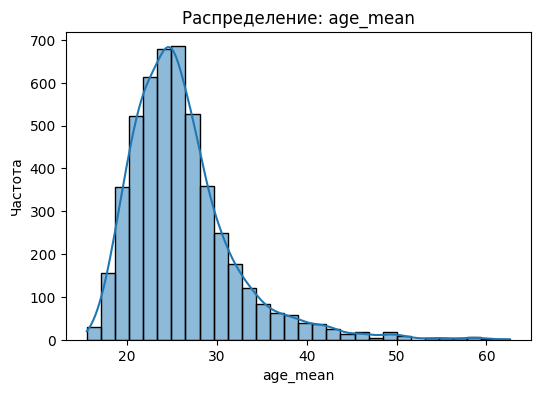

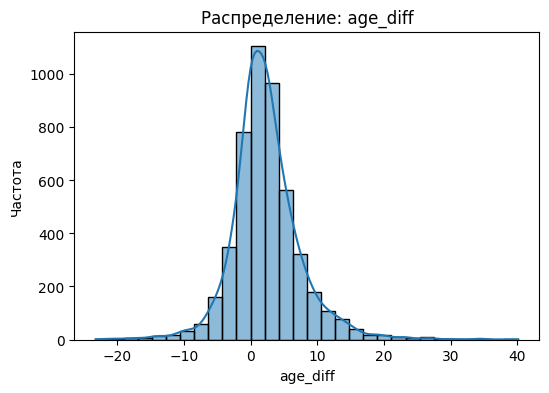

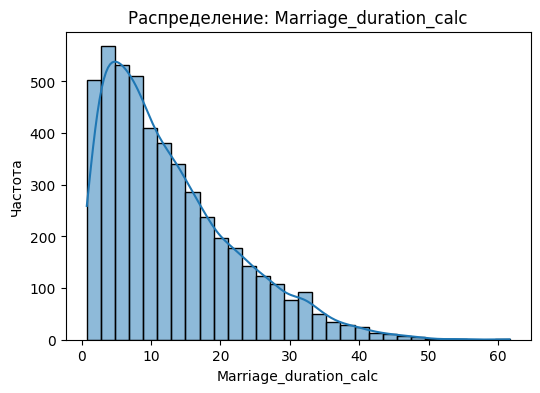

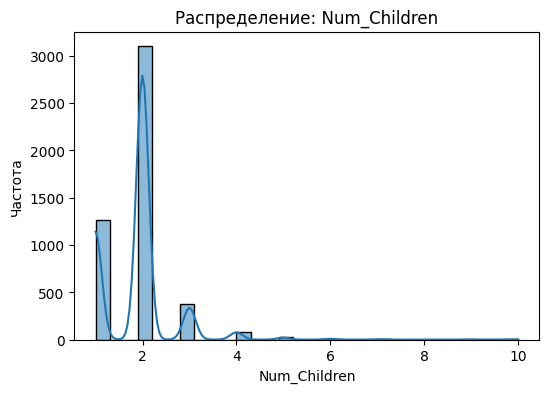

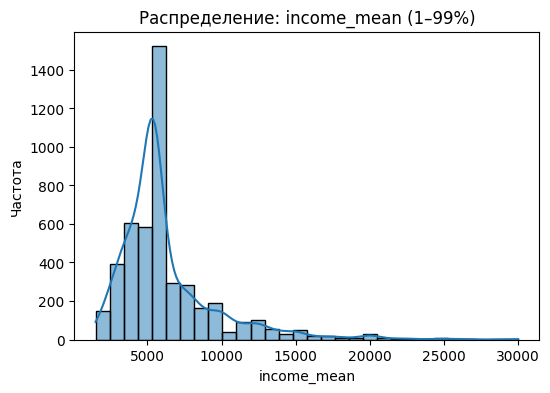

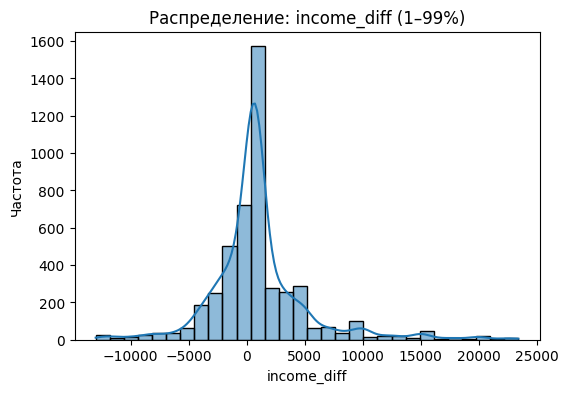

In [15]:
for col in num_cols_1:
    plt.figure(figsize=(6, 4))
    
    sns.histplot(df_eda[col], kde=True, bins=30)
    
    plt.title(f"Распределение: {col}")
    plt.xlabel(col)
    plt.ylabel("Частота")
    
    plt.show()

for col in num_cols_2:
    plt.figure(figsize=(6, 4))
    
    sns.histplot(df_plot[col], kde=True, bins=30)
    
    plt.title(f"Распределение: {col} (1–99%)")
    plt.xlabel(col)
    plt.ylabel("Частота")
    
    plt.show()

##### 2. Асимметрия (skewness)

In [16]:
print("Асимметрия распределений:\n")

for col in num_cols:
    skew_val = df_plot[col].skew()
    print(f"{col:30s}: {skew_val:.3f}")

Асимметрия распределений:

age_mean                      : 1.693
age_diff                      : 0.810
Marriage_duration_calc        : 1.074
Num_Children                  : 2.128
income_mean                   : 2.242
income_diff                   : 1.374


##### 3. Базовая проверка диапазонов

In [17]:
print("\nОписание диапазонов:\n")
display((df_plot[num_cols].describe()).round(2))


Описание диапазонов:



,age_mean,age_diff,Marriage_duration_calc,Num_Children,income_mean,income_diff
count,4674.00,4674.00,4674.00,4674.00,4674.00,4674.00
mean,26.07,2.30,12.72,1.89,6271.63,1015.52
std,5.89,5.23,9.42,0.72,3438.13,4214.61
min,15.52,-23.28,0.75,1.00,1500.00,-13000.00
25%,22.18,-0.46,5.34,1.00,4400.00,-700.00
50%,24.96,1.89,10.38,2.00,5400.00,800.00
75%,28.35,4.63,17.84,2.00,7000.00,2000.00
max,62.56,40.15,61.62,10.00,30000.00,23400.00


#### 4.2 Выявление выбросов и аномалий

##### 0. Выбросы

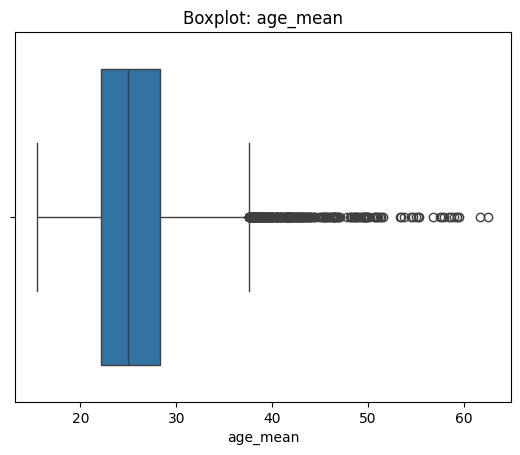

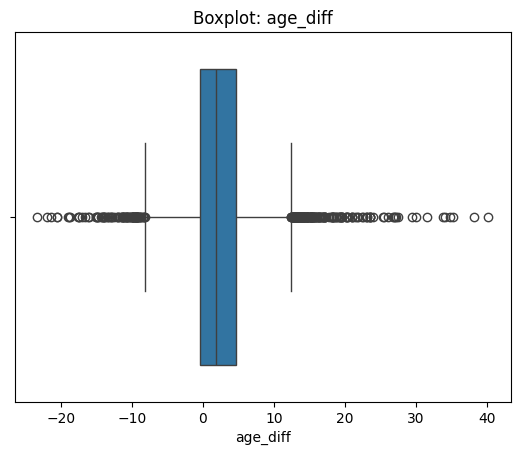

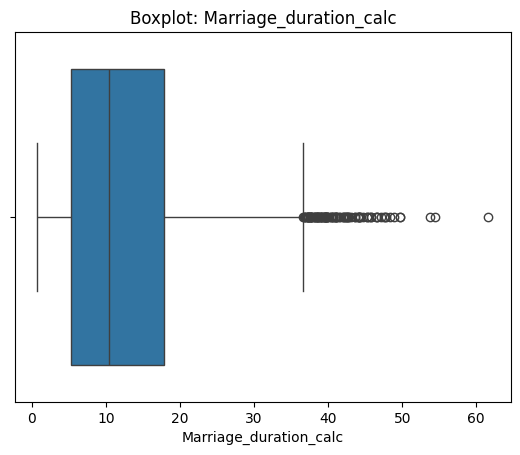

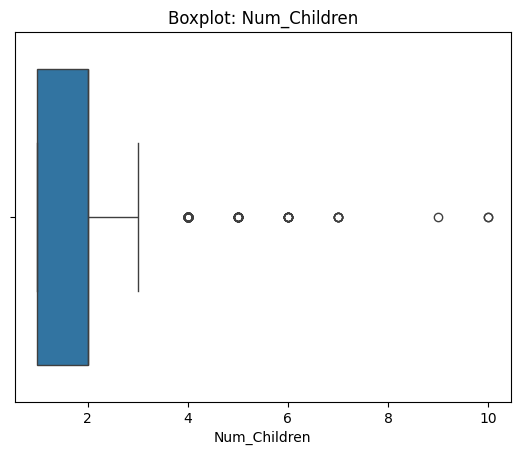

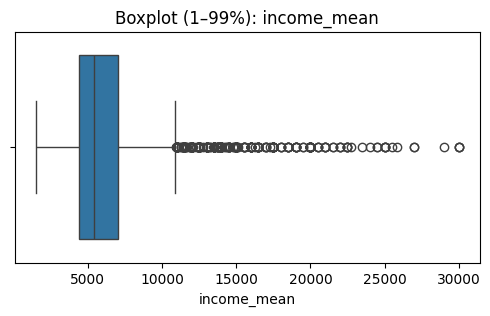

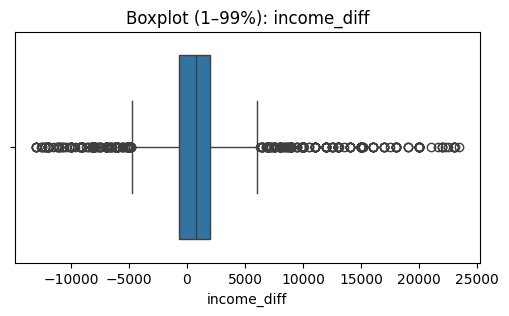

In [18]:
for col in num_cols_1:
    plt.figure()
    sns.boxplot(x=df_eda[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

for col in num_cols_2:
    plt.figure(figsize=(6, 3))
    
    sns.boxplot(x=df_plot[col])
    
    plt.title(f"Boxplot (1–99%): {col}")
    plt.show()

##### 1. Возрастные аномалии (если ещё остались)

In [19]:
# возрастные аномалии (если ещё остались)
age_anomalies = df_eda[
    (df_eda['age_mean'] < 15) | (df_eda['age_mean'] > 80)
]

# дети (реалистичный диапазон)
children_anomalies = df_eda[
    (df_eda['Num_Children'] > 8)
]

print("Возрастные аномалии:", len(age_anomalies))
print("Аномалии по количеству детей:", len(children_anomalies))

Возрастные аномалии: 0
Аномалии по количеству детей: 3


##### 2. Длина хвоста

In [20]:
def iqr_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    
    return df[(df[col] < low) | (df[col] > high)]


for col in num_cols:
    outliers = iqr_outliers(df_eda, col)
    print(f"{col:25s}: {len(outliers)} выбросов")

age_mean                 : 239 выбросов
age_diff                 : 280 выбросов
Marriage_duration_calc   : 102 выбросов
Num_Children             : 125 выбросов
income_mean              : 461 выбросов
income_diff              : 657 выбросов


##### 3. Экстремальные значения у зп

In [21]:
for col in ['income_mean', 'income_diff']:
    low = df_eda[col].quantile(0.01)
    high = df_eda[col].quantile(0.99)
    
    outliers = df_eda[(df_eda[col] < low) | (df_eda[col] > high)]
    
    print(f"{col}: {len(outliers)} экстремальных значений (1–99%)")

income_mean: 93 экстремальных значений (1–99%)
income_diff: 92 экстремальных значений (1–99%)


#### 4.3 Исследование зависимостей между признаками

##### 1. Корреляция числовых признаков

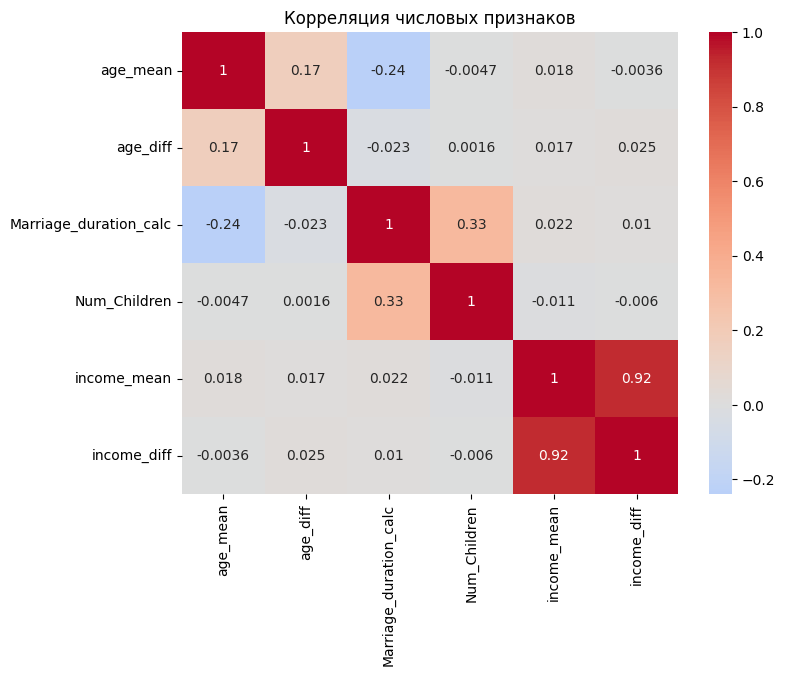

In [22]:
corr = df_eda[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Корреляция числовых признаков")
plt.show()

##### 2. Распределение пар

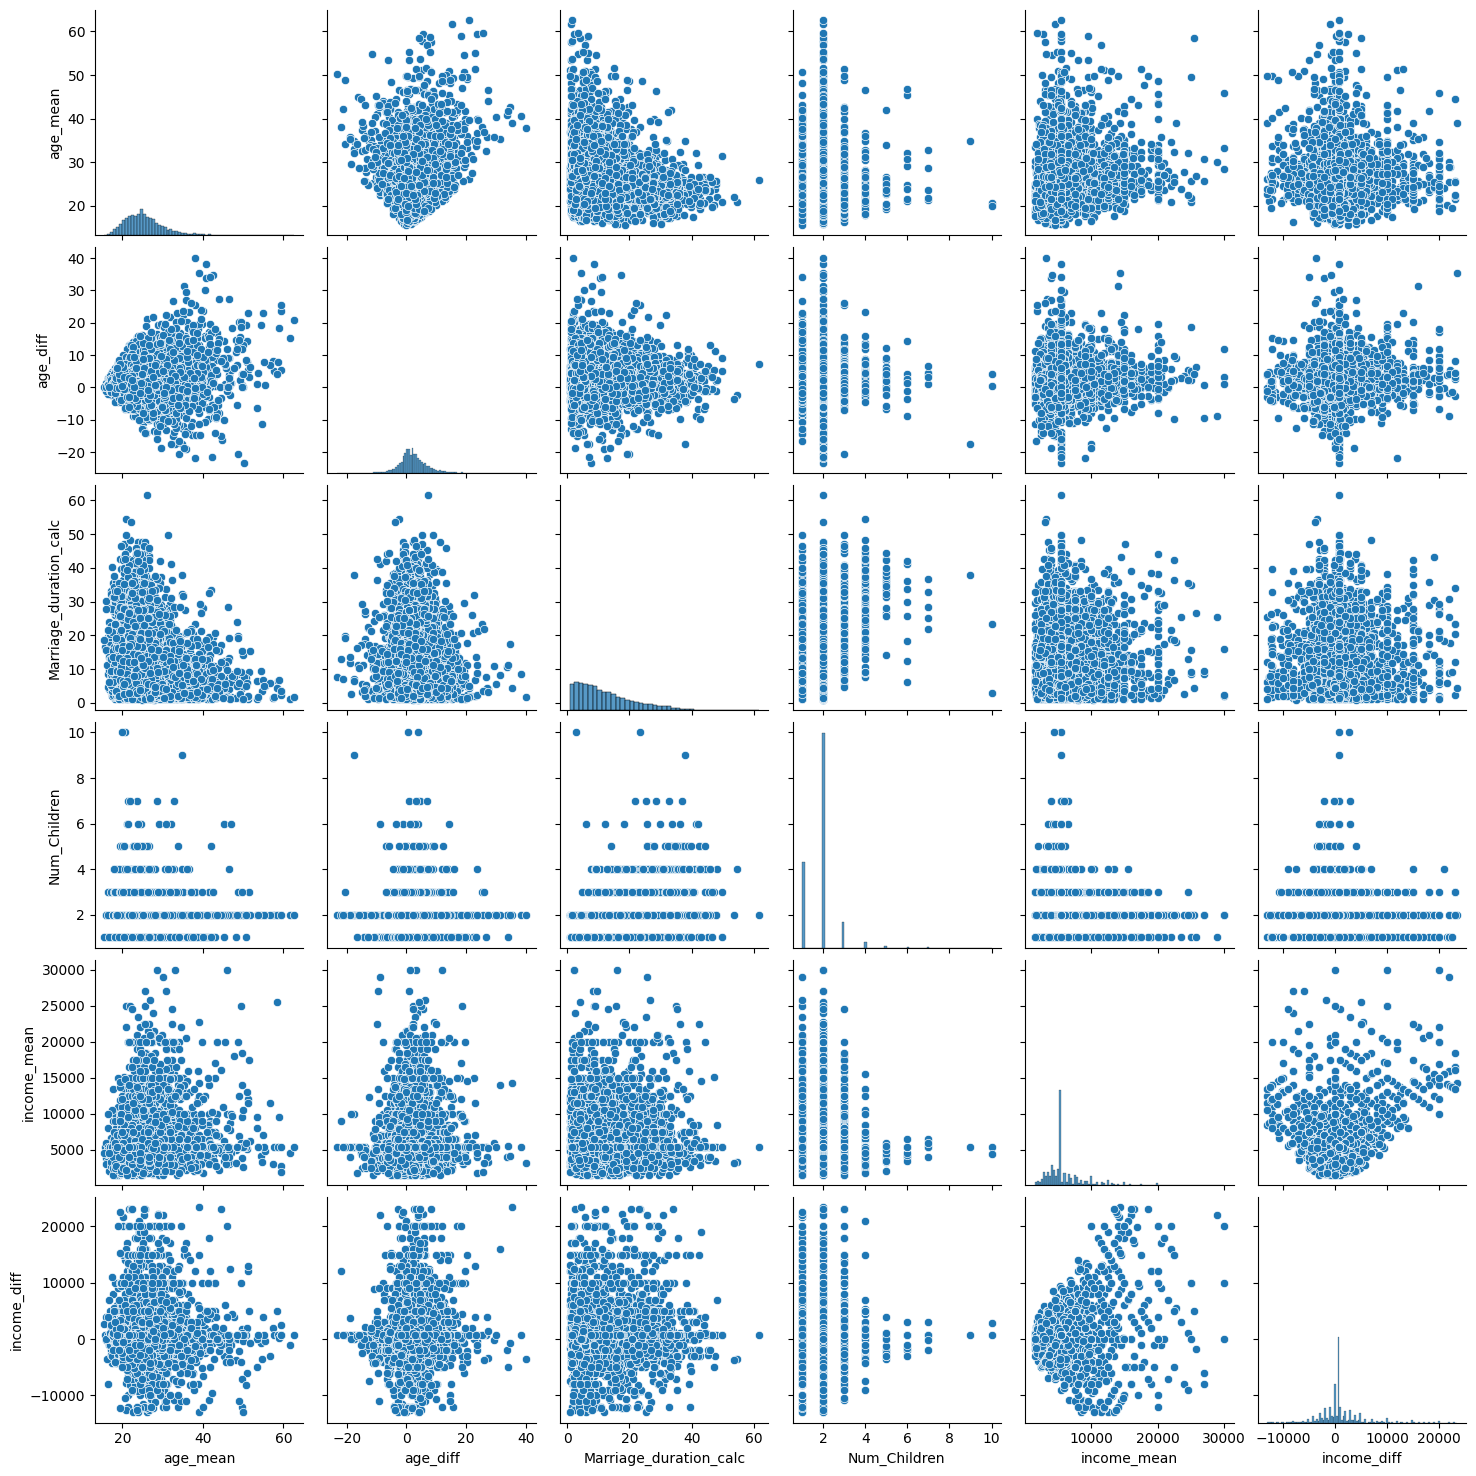

In [55]:
sns.pairplot(df_plot[num_cols])
plt.show()

#### 4.4 Анализ категориальных признаков

##### 0. Задаем поле

In [24]:
# Категории
cat_cols = [
    'Type_of_divorce',                     # тип развода
    'Nationality_partner_man',             # гражданство мужчины
    'Nationality_partner_woman',           # гражданство женщины
    'Occupation_partner_man',              # профессия мужчины
    'Occupation_partner_woman',            # профессия женщины
    'Level_of_education_partner_man',      # образование мужчины
    'Level_of_education_partner_woman',    # образование женщины
    'Employment_status_partner_man',       # занятость мужчины
    'Employment_status_partner_woman'      # занятость женщины
]

##### 1. Уникальные значения

In [56]:
# Тип развода

pare_nat = df_eda['Type_of_divorce'].copy()


# считаем
pare_counts = pare_nat.value_counts().to_frame('count')

print("Тип развода:")
display(pare_counts)

Тип развода:


,count
Type_of_divorce,
Necesario,2493
Voluntario,2370


In [25]:
# Национальности (Мексиканцы/остальные)

man_nat = df_eda['Nationality_partner_man'].copy()
woman_nat = df_eda['Nationality_partner_woman'].copy()

man_nat_grouped = man_nat.where(man_nat == 'MEXICANA', 'Other')
woman_nat_grouped = woman_nat.where(woman_nat == 'MEXICANA', 'Other')


# считаем
man_counts = man_nat_grouped.value_counts().to_frame('count')
woman_counts = woman_nat_grouped.value_counts().to_frame('count')

print("Гражданство мужчин (Mexico vs Other):")
display(man_counts)

print("Гражданство женщин (Mexico vs Other):")
display(woman_counts)

Гражданство мужчин (Mexico vs Other):


,count
Nationality_partner_man,
MEXICANA,4819
Other,44


Гражданство женщин (Mexico vs Other):


,count
Nationality_partner_woman,
MEXICANA,4830
Other,33


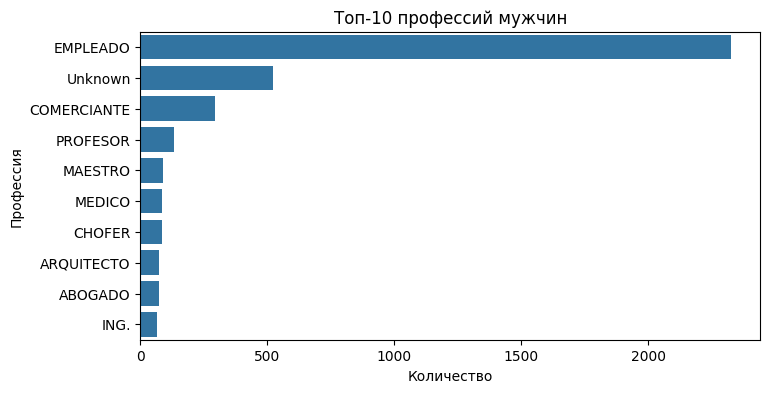

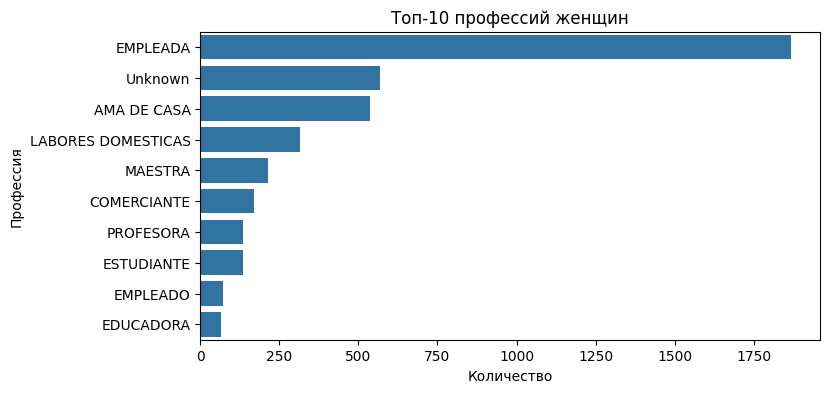

In [26]:
# Топ профессий
top10_man = df_eda['Occupation_partner_man'].value_counts().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=top10_man.values, y=top10_man.index)

plt.title("Топ-10 профессий мужчин")
plt.xlabel("Количество")
plt.ylabel("Профессия")
plt.show()


top10_woman = df_eda['Occupation_partner_woman'].value_counts().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=top10_woman.values, y=top10_woman.index)

plt.title("Топ-10 профессий женщин")
plt.xlabel("Количество")
plt.ylabel("Профессия")
plt.show()

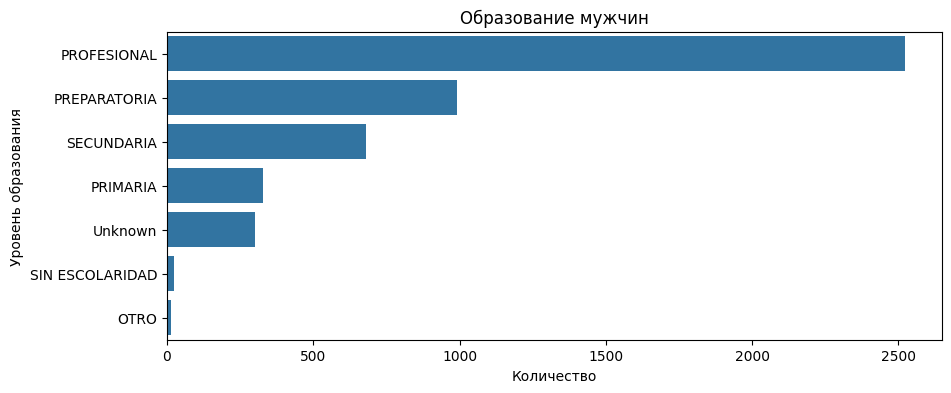

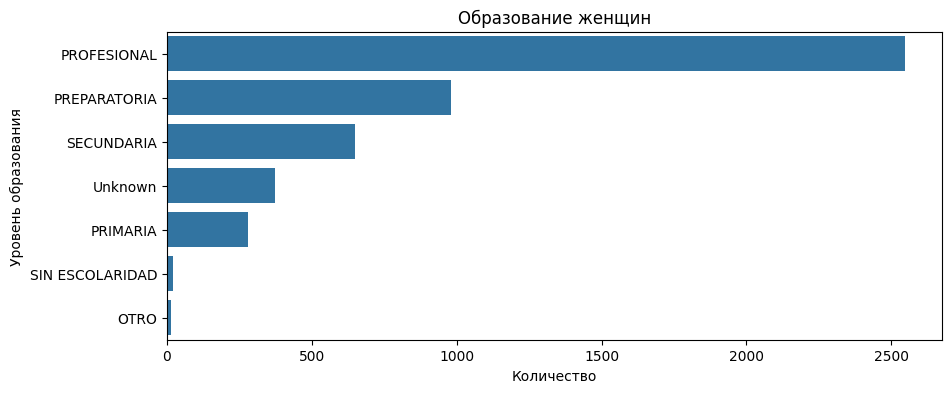

In [27]:
# Образование
# М
plt.figure(figsize=(10, 4))

sns.countplot(
    data=df_eda,
    y='Level_of_education_partner_man',
    order=df_eda['Level_of_education_partner_man'].value_counts().index
)

plt.title("Образование мужчин")
plt.xlabel("Количество")
plt.ylabel("Уровень образования")
plt.show()

# Ж
plt.figure(figsize=(10, 4))

sns.countplot(
    data=df_eda,
    y='Level_of_education_partner_woman',
    order=df_eda['Level_of_education_partner_woman'].value_counts().index
)

plt.title("Образование женщин")
plt.xlabel("Количество")
plt.ylabel("Уровень образования")
plt.show()

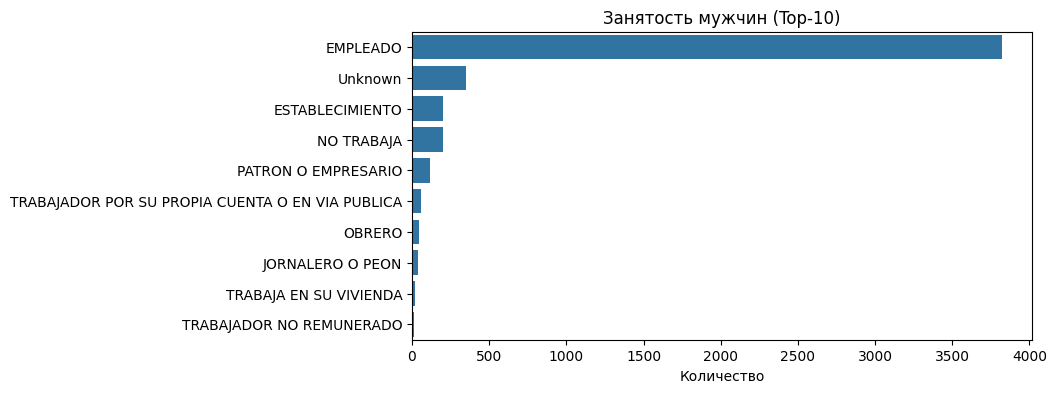

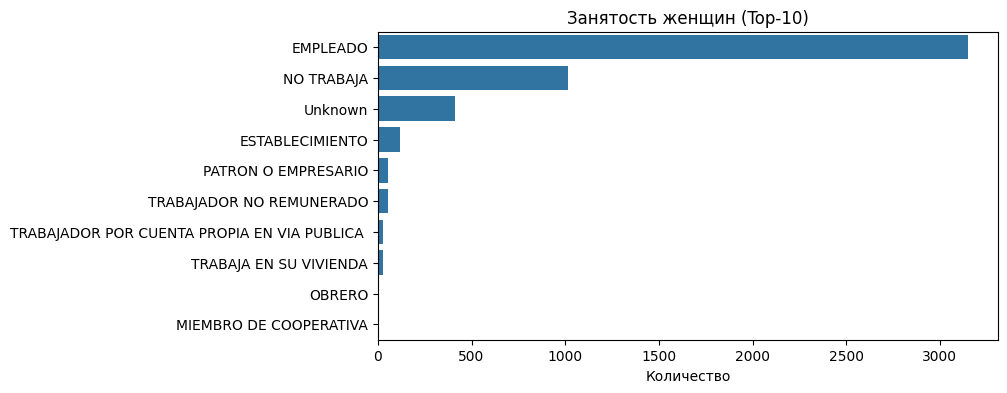

In [28]:
# Занятость (топ 10)
top_emp_man = df_eda['Employment_status_partner_man'].value_counts().head(10)
top_emp_woman = df_eda['Employment_status_partner_woman'].value_counts().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_emp_man.values, y=top_emp_man.index)
plt.title("Занятость мужчин (Top-10)")
plt.xlabel("Количество")
plt.ylabel("")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x=top_emp_woman.values, y=top_emp_woman.index)
plt.title("Занятость женщин (Top-10)")
plt.xlabel("Количество")
plt.ylabel("")
plt.show()

##### 2. Групповой анализ

In [58]:
# ================================
# ⚖️ 0. Тип развода (Necesario vs Voluntario)
# ================================

print("\n===== Тип развода =====")
display(
    df_eda.groupby('Type_of_divorce')[num_cols]
    .mean()
    .round(2)
)


===== Тип развода =====


,age_mean,age_diff,Marriage_duration_calc,Num_Children,income_mean,income_diff
Type_of_divorce,,,,,,
Necesario,25.39,2.17,15.20,1.84,8399.69,3895.14
Voluntario,26.79,2.48,10.15,1.93,7441.97,2320.51


In [29]:
# ================================
# 🌍 1. НАЦИОНАЛЬНОСТЬ (MEX vs Other)
# ================================
df_eda['nat_man_grp'] = df_eda['Nationality_partner_man'].where(
    df_eda['Nationality_partner_man'] == 'MEXICANA', 'Other'
)

df_eda['nat_woman_grp'] = df_eda['Nationality_partner_woman'].where(
    df_eda['Nationality_partner_woman'] == 'MEXICANA', 'Other'
)


print("\n===== Национальность мужчин =====")
display(df_eda.groupby('nat_man_grp')[num_cols].mean().round(2))

print("\n===== Национальность женщин =====")
display(df_eda.groupby('nat_woman_grp')[num_cols].mean().round(2))


===== Национальность мужчин =====


,age_mean,age_diff,Marriage_duration_calc,Num_Children,income_mean,income_diff
nat_man_grp,,,,,,
MEXICANA,26.04,2.33,12.78,1.88,7929.46,3132.78
Other,29.80,2.09,8.58,1.89,8314.77,2575.00



===== Национальность женщин =====


,age_mean,age_diff,Marriage_duration_calc,Num_Children,income_mean,income_diff
nat_woman_grp,,,,,,
MEXICANA,26.04,2.32,12.76,1.88,7927.92,3135.84
Other,30.39,2.95,10.28,1.79,8668.18,1942.42


📌 вывод:
- национальность связана с демографическими различиями, но не является сильным фактором различий доходов внутри выборки.

In [30]:
# ================================
# 💼 2. ПРОФЕССИИ (TOP-10)
# ================================
top_man_jobs = df_eda['Occupation_partner_man'].value_counts().head(10).index
top_woman_jobs = df_eda['Occupation_partner_woman'].value_counts().head(10).index

df_jobs_man = df_eda[df_eda['Occupation_partner_man'].isin(top_man_jobs)]
df_jobs_woman = df_eda[df_eda['Occupation_partner_woman'].isin(top_woman_jobs)]

print("\n===== ТОП-10 профессий мужчин =====")
display(df_jobs_man.groupby('Occupation_partner_man')[num_cols].mean().round(2))

print("\n===== ТОП-10 профессий женщин =====")
display(df_jobs_woman.groupby('Occupation_partner_woman')[num_cols].mean().round(2))


===== ТОП-10 профессий мужчин =====


,age_mean,age_diff,Marriage_duration_calc,Num_Children,income_mean,income_diff
Occupation_partner_man,,,,,,
ABOGADO,27.26,2.70,11.73,1.78,9417.60,2433.30
ARQUITECTO,27.05,3.29,13.19,1.81,10108.78,4195.95
CHOFER,24.26,2.50,17.32,1.98,4746.47,-354.12
COMERCIANTE,26.61,2.90,13.90,1.96,7450.67,2695.89
EMPLEADO,25.35,2.04,11.63,1.83,8009.67,3526.95
ING.,28.11,2.60,10.82,1.85,9077.54,1659.69
MAESTRO,26.48,3.28,14.13,1.84,7890.11,443.15
MEDICO,28.33,3.01,15.10,2.01,9914.23,3004.60
PROFESOR,27.34,2.54,12.96,1.85,7549.31,2329.56



===== ТОП-10 профессий женщин =====


,age_mean,age_diff,Marriage_duration_calc,Num_Children,income_mean,income_diff
Occupation_partner_woman,,,,,,
AMA DE CASA,25.92,2.84,16.31,2.07,6304.63,2448.43
COMERCIANTE,26.17,2.34,15.40,2.01,6410.47,2144.47
EDUCADORA,26.71,1.49,10.82,1.81,8119.06,556.88
EMPLEADA,25.71,2.11,11.37,1.82,7807.87,2086.24
EMPLEADO,25.95,2.49,11.34,1.78,21338.08,28964.22
ESTUDIANTE,22.47,3.80,4.06,1.78,6183.69,2347.98
LABORES DOMESTICAS,25.44,3.16,14.48,2.03,7123.07,4376.52
MAESTRA,27.55,1.96,12.45,1.77,7243.38,1232.66
PROFESORA,26.80,1.35,15.80,1.93,9997.20,4678.61


📌 вывод:
- у женщин сильнее выражена связь между профессией и экономической ролью
- часть категорий отражает не работу, а социальную роль

In [31]:
# ================================
# 🎓 3. ОБРАЗОВАНИЕ (ВСЕ)
# ================================
print("\n===== Образование мужчин =====")
display(df_eda.groupby('Level_of_education_partner_man')[num_cols].mean().round(2))

print("\n===== Образование женщин =====")
display(df_eda.groupby('Level_of_education_partner_woman')[num_cols].mean().round(2))



===== Образование мужчин =====


,age_mean,age_diff,Marriage_duration_calc,Num_Children,income_mean,income_diff
Level_of_education_partner_man,,,,,,
OTRO,29.00,2.53,12.02,2.21,6835.71,471.43
PREPARATORIA,24.76,1.82,11.40,1.82,6331.96,1182.34
PRIMARIA,27.12,2.88,18.60,2.26,5538.54,2139.84
PROFESIONAL,26.97,2.57,12.02,1.85,9858.15,5003.97
SECUNDARIA,24.18,1.66,13.24,1.88,5504.13,722.29
SIN ESCOLARIDAD,27.93,0.48,20.15,2.75,3879.17,-566.67
Unknown,25.78,2.92,15.07,1.88,5547.88,743.10



===== Образование женщин =====


,age_mean,age_diff,Marriage_duration_calc,Num_Children,income_mean,income_diff
Level_of_education_partner_woman,,,,,,
OTRO,25.67,-0.20,14.30,1.54,6890.38,319.23
PREPARATORIA,24.46,2.57,11.45,1.85,6300.22,2678.33
PRIMARIA,26.39,2.65,19.37,2.42,5895.38,2107.03
PROFESIONAL,27.13,2.17,11.58,1.81,9817.63,4234.49
SECUNDARIA,24.26,2.52,14.34,1.96,5465.40,1492.33
SIN ESCOLARIDAD,28.47,2.20,21.06,2.86,4609.09,-781.82
Unknown,25.93,2.24,15.73,1.87,5389.00,675.85


📌 вывод:
- образование — один из самых сильных структурных факторов в данных

In [32]:
# ================================
# 🧑‍💼 4. ЗАНЯТОСТЬ (TOP-10)
# ================================
top_emp_man = df_eda['Employment_status_partner_man'].value_counts().head(10).index
top_emp_woman = df_eda['Employment_status_partner_woman'].value_counts().head(10).index

df_emp_man = df_eda[df_eda['Employment_status_partner_man'].isin(top_emp_man)]
df_emp_woman = df_eda[df_eda['Employment_status_partner_woman'].isin(top_emp_woman)]

print("\n===== Занятость мужчин (TOP-10) =====")
display(df_emp_man.groupby('Employment_status_partner_man')[num_cols].mean().round(2))

print("\n===== Занятость женщин (TOP-10) =====")
display(df_emp_woman.groupby('Employment_status_partner_woman')[num_cols].mean().round(2))



===== Занятость мужчин (TOP-10) =====


,age_mean,age_diff,Marriage_duration_calc,Num_Children,income_mean,income_diff
Employment_status_partner_man,,,,,,
EMPLEADO,26.07,2.24,12.27,1.86,8319.65,3575.26
ESTABLECIMIENTO,26.40,2.57,13.02,1.91,6781.30,2024.46
JORNALERO O PEON,28.10,2.30,16.79,2.33,4140.28,-402.78
NO TRABAJA,25.54,2.00,15.39,2.16,7886.70,1154.29
OBRERO,27.40,1.79,15.01,1.95,4411.63,-497.67
PATRON O EMPRESARIO,26.92,2.92,13.51,2.00,8818.62,4923.37
TRABAJA EN SU VIVIENDA,26.14,3.81,14.45,2.06,5562.53,-374.94
TRABAJADOR NO REMUNERADO,25.28,4.69,20.47,1.83,5262.50,1275.00
TRABAJADOR POR SU PROPIA CUENTA O EN VIA PUBLICA,25.14,4.65,13.80,1.98,4680.83,-368.33



===== Занятость женщин (TOP-10) =====


,age_mean,age_diff,Marriage_duration_calc,Num_Children,income_mean,income_diff
Employment_status_partner_woman,,,,,,
EMPLEADO,26.37,2.14,11.69,1.83,8726.63,3438.57
ESTABLECIMIENTO,26.83,2.70,13.34,1.83,7518.47,3233.58
MIEMBRO DE COOPERATIVA,22.18,3.01,34.30,3.00,13800.00,0.00
NO TRABAJA,25.23,2.96,14.46,2.02,6712.03,3381.30
OBRERO,24.19,4.27,19.10,1.75,4012.50,775.00
PATRON O EMPRESARIO,27.49,2.05,11.96,1.91,8102.62,1259.02
TRABAJA EN SU VIVIENDA,23.98,2.06,16.35,2.40,6480.20,-183.60
TRABAJADOR NO REMUNERADO,26.79,1.99,16.57,2.04,5606.48,1435.19
TRABAJADOR POR CUENTA PROPIA EN VIA PUBLICA,23.36,2.10,15.82,2.11,4292.78,259.63


📌 наблюдение:

- занятость сильно сегментирует доход
- есть классовая структура внутри данных

### 5. Кластеризация

#### 5.0 Зададим поле

In [42]:
# Признаки для кластеризации
cluster_cols = [
    # Параметры
    'age_mean',
    'age_diff', 
    'income_mean',
    'Num_Children', 
    'Marriage_duration_calc'
]

# Датасет
df_cluster = df[cluster_cols].copy()

#### 5.1 Выбор признаков для кластеризации

Для кластеризации используются следующие числовые признаки:

- age_mean — средний возраст пары
- age_diff — разница в возрасте
- income_mean — средний доход пары
- Num_Children — количество детей
- Marriage_duration_calc — длительность брака

Дополнительно включены индикаторы пропусков:

- Monthly_income_partner_man_peso_missing
- Monthly_income_partner_woman_peso_missing
- Num_Children_missing
- age_at_marriage_man_missing
- age_at_marriage_woman_missing

##### Исключённые признаки

Признак income_diff (разница в доходах) исключён из кластеризации, так как он сильно коррелирует с income_mean, что может привести к переусилению влияния дохода и искажению результатов кластеризации.

#### 5.2 Масштабирование данных

In [43]:
# инициализация scaler
scaler = StandardScaler()

# масштабируем
X_scaled = scaler.fit_transform(df_cluster)

# обратно в DataFrame для удобства
X_scaled = pd.DataFrame(X_scaled, columns=df_cluster.columns)

# просмотр
print("Первые 5 строк масштабированных данных:")
display(X_scaled.head())

Первые 5 строк масштабированных данных:


,age_mean,age_diff,income_mean,Num_Children,Marriage_duration_calc
0,-0.862700,0.904282,-0.189755,-1.215493,-0.719005
1,-0.858967,0.701420,-0.079669,0.161707,1.084578
2,-0.217185,-1.957228,-0.079669,0.161707,1.739212
3,-0.373723,-0.441511,-0.076524,0.161707,0.576613
4,-0.765418,0.120543,0.112195,0.161707,-0.584825


#### 5.3 K-Means

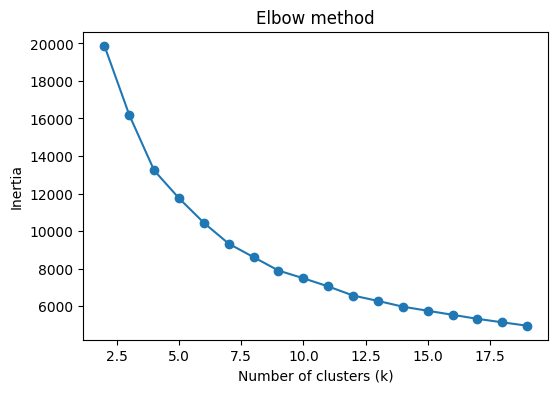

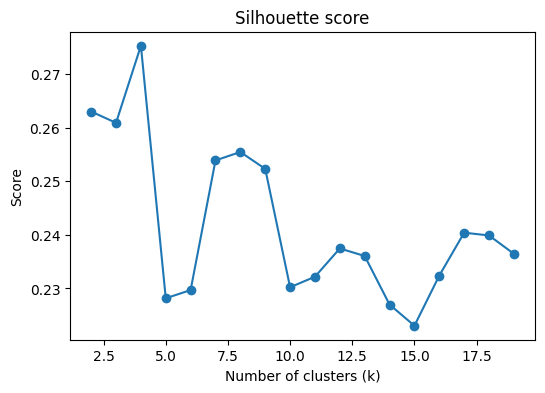

In [44]:
# Определение оптимального числа кластеров

k_range = range(2, 20)

inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# 1. Elbow method
plt.figure(figsize=(6, 4))
plt.plot(k_range, inertias, marker='o')
plt.title("Elbow method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

# 2. Silhouette score
plt.figure(figsize=(6, 4))
plt.plot(k_range, silhouettes, marker='o')
plt.title("Silhouette score")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Score")
plt.show()

##### 📌 Вывод
Метрики не выявили выраженного оптимального числа кластеров, что указывает на слабую или отсутствующую кластерную структуру, подходящую для K-Means.

Поэтому далее проводится визуализация через PCA (2D и 3D), чтобы посмотреть как распределены данные и действительно ли их нельзя хорошо разбить на компоненты.

Дополнительно на пониженное пространство накладывается разбиение K-Means.

#### 5.4 PCA-анализ структуры данных + K-Means

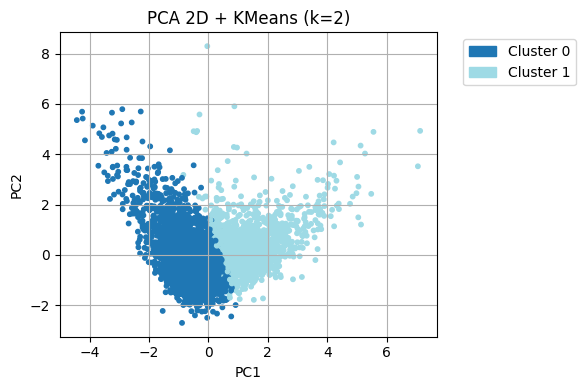

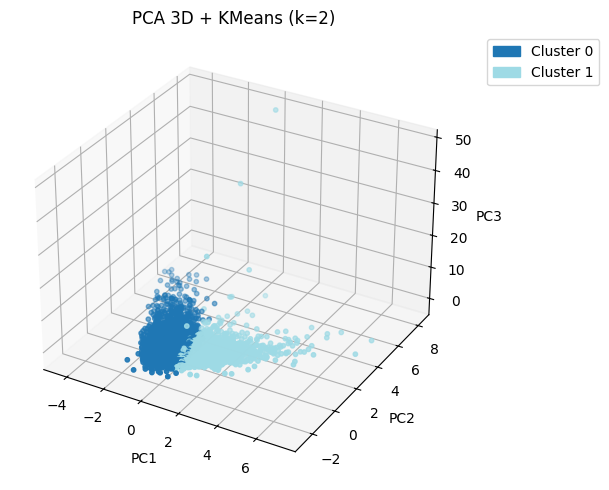

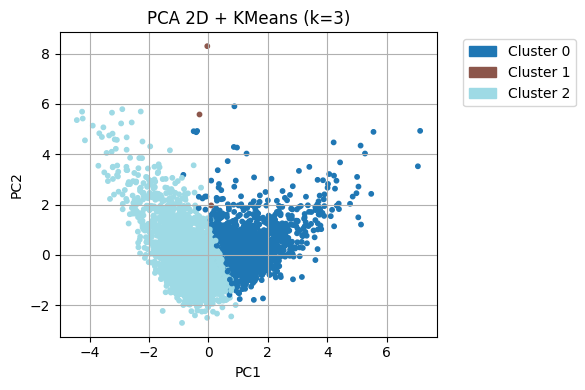

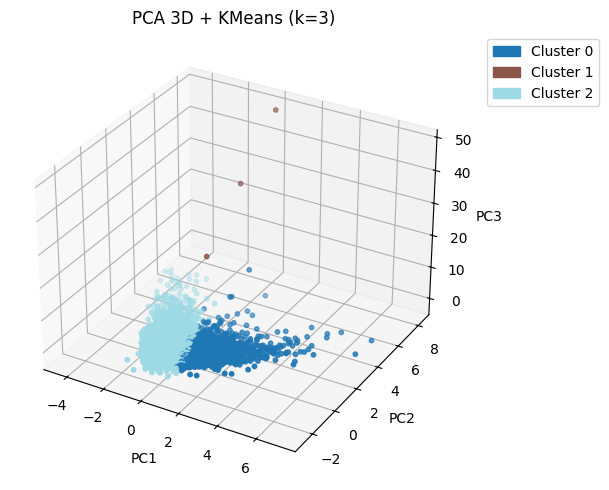

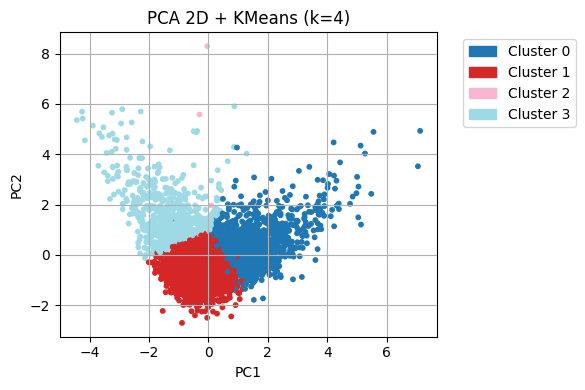

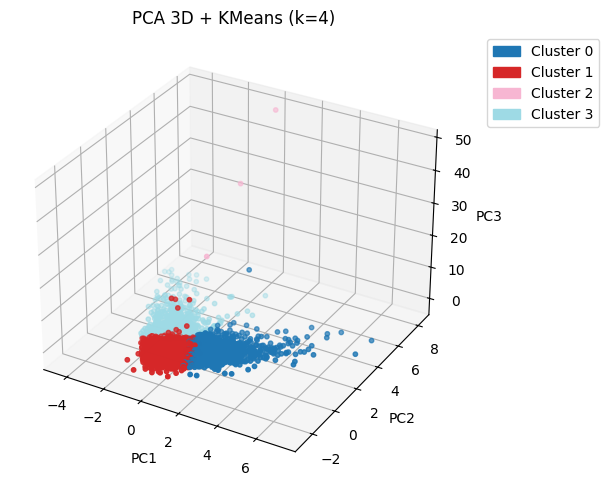

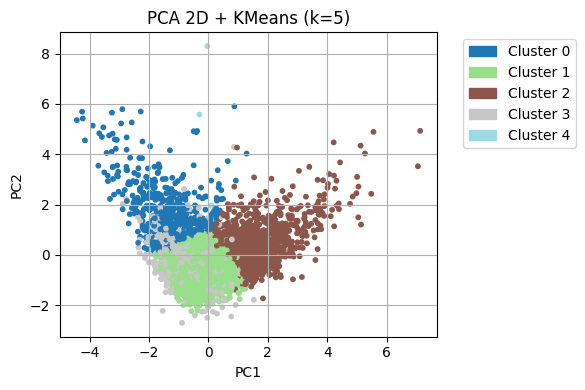

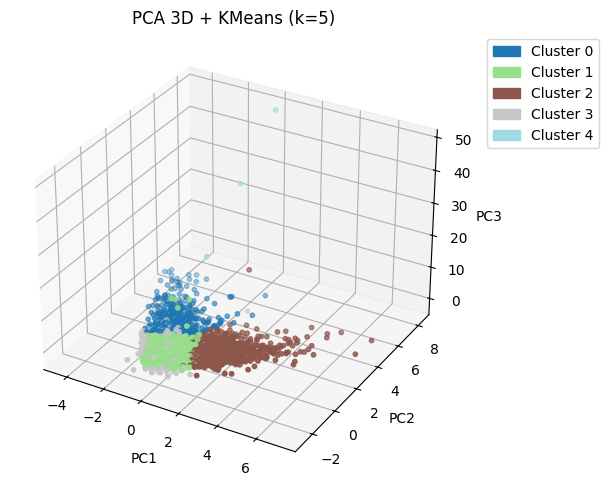

In [45]:
# =========================
# диапазон k
# =========================
ks = range(2, 6)

# =========================
# PCA (2D и 3D)
# =========================
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# =========================
# запуск k-means
# =========================
for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    cmap = plt.colormaps['tab20'].resampled(k)

    # =========================
    # 2D
    # =========================
    plt.figure(figsize=(6, 4))

    scatter = plt.scatter(
        X_pca_2d[:, 0],
        X_pca_2d[:, 1],
        c=labels,
        cmap=cmap,
        s=10
    )

    plt.title(f"PCA 2D + KMeans (k={k})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid()

    unique_labels = np.unique(labels)

    handles = [
        mpatches.Patch(color=cmap(i), label=f"Cluster {i}")
        for i in unique_labels
    ]

    plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # =========================
    # 3D
    # =========================
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        X_pca_3d[:, 0],
        X_pca_3d[:, 1],
        X_pca_3d[:, 2],
        c=labels,
        cmap=cmap,
        s=10
    )

    ax.set_title(f"PCA 3D + KMeans (k={k})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    handles = [
        mpatches.Patch(color=cmap(i), label=f"Cluster {i}")
        for i in unique_labels
    ]

    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

##### Вывод: 

Визуализация показывает наличие вытянутых структур и неоднородных областей.
При этом K-Means делит такие структуры некорректно, разбивая их на части, что связано с предположением алгоритма о сферической форме кластеров.

#### 5.5 DBSCAN

In [46]:
eps = 1.377
min_samples = 20

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

print("Количество кластеров:", len(set(labels)) - (1 if -1 in labels else 0))
print("Шум (noise):", np.sum(labels == -1))

Количество кластеров: 4
Шум (noise): 106


#### 5.6 PCA-анализ структуры данных + DBSCAN

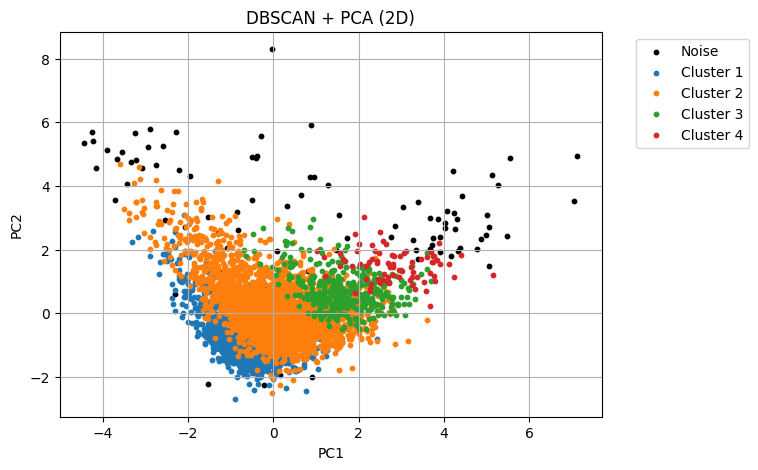

In [47]:
# =========================
# PCA 2D
# =========================
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# =========================
# подписи кластеров
# =========================
unique_labels = sorted(set(labels))

label_names = {}
cluster_id = 1

for lab in unique_labels:
    if lab == -1:
        label_names[lab] = "Noise"
    else:
        label_names[lab] = f"Cluster {cluster_id}"
        cluster_id += 1

# =========================
# визуализация (2D)
# =========================
plt.figure(figsize=(7, 5))

for lab in unique_labels:
    if lab == -1:
        plt.scatter(
            X_pca_2d[labels == lab, 0],
            X_pca_2d[labels == lab, 1],
            s=10,
            c="black",
            label="Noise"
        )
    else:
        plt.scatter(
            X_pca_2d[labels == lab, 0],
            X_pca_2d[labels == lab, 1],
            s=10,
            label=label_names[lab]
        )

plt.title("DBSCAN + PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

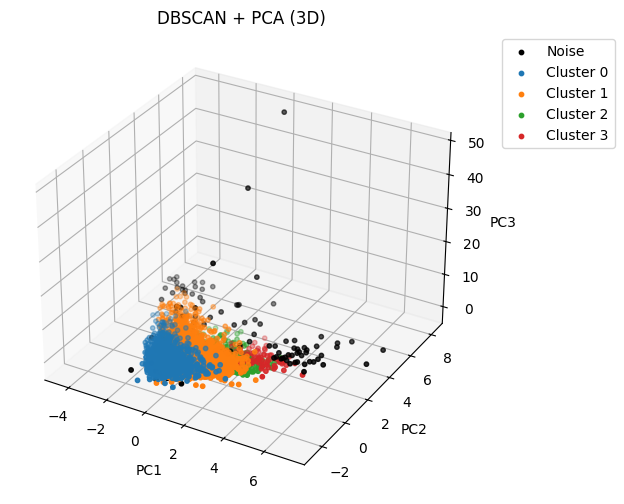

In [48]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

unique_labels = np.unique(labels)

for lab in unique_labels:
    if lab == -1:
        ax.scatter(
            X_pca_3d[labels == lab, 0],
            X_pca_3d[labels == lab, 1],
            X_pca_3d[labels == lab, 2],
            s=10,
            c="black",
            label="Noise"
        )
    else:
        ax.scatter(
            X_pca_3d[labels == lab, 0],
            X_pca_3d[labels == lab, 1],
            X_pca_3d[labels == lab, 2],
            s=10,
            label=f"Cluster {lab}"
        )

ax.set_title("DBSCAN + PCA (3D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

#### 5.6 PCA

In [49]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_

print("Explained variance ratio:")
for i, v in enumerate(explained):
    print(f"PC{i+1}: {v:.4f}")

print("\nCumulative variance:")
print(np.cumsum(explained))

Explained variance ratio:
PC1: 0.2854
PC2: 0.2255
PC3: 0.1999
PC4: 0.1717
PC5: 0.1175

Cumulative variance:
[0.2853891  0.51090913 0.71079745 0.8825104  1.        ]


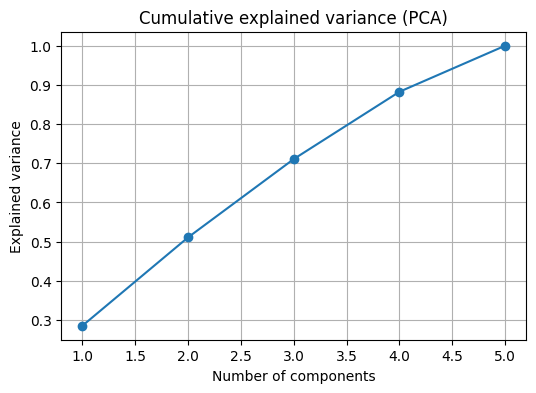

In [50]:
plt.figure(figsize=(6, 4))

plt.plot(
    range(1, len(explained) + 1),
    np.cumsum(explained),
    marker='o'
)

plt.title("Cumulative explained variance (PCA)")
plt.xlabel("Number of components")
plt.ylabel("Explained variance")
plt.grid()

plt.show()

##### Вывод

Данные живут в 5D пространстве, каждый признак важен

In [53]:
pca = PCA()
pca.fit(X_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(df_cluster.columns))],
    index=df_cluster.columns
)

print(loadings)

                             PC1       PC2       PC3       PC4       PC5
age_mean               -0.472126  0.509279 -0.090873 -0.549711  0.455293
age_diff               -0.220717  0.664544 -0.063257  0.696350 -0.144087
income_mean            -0.006988  0.150782  0.983985 -0.069963 -0.063983
Num_Children            0.521666  0.486520 -0.136171 -0.423391 -0.541627
Marriage_duration_calc  0.675423  0.198946  0.031160  0.169588  0.688835


##### Вывод

Анализ главных компонент показал, что данные описываются несколькими независимыми факторами: уровнем дохода, возрастными характеристиками и семейной стадией (длительность брака и наличие детей).

При этом данные факторы слабо коррелируют между собой и формируют непрерывное пространство признаков, а не дискретные группы. Это объясняет отсутствие выраженной кластерной структуры.

### 6. Анализ результатов

### 6.1 Вывод

В ходе исследования были применены методы кластеризации K-Means и DBSCAN для выявления типичных групп супружеских пар, завершивших брак разводом.

Однако ни один из методов не продемонстрировал устойчивой и интерпретируемой кластерной структуры. Метрики качества (silhouette score), а также визуализация с использованием PCA показали, что данные не разделяются на чёткие группы, а образуют непрерывное распределение в признаковом пространстве.

Это свидетельствует о том, что различия между парами носят скорее плавный, континуальный характер, а не формируют дискретные типы.

Таким образом, факторы, такие как возраст, доход и другие социально-экономические характеристики, не разделяют наблюдения на чёткие кластеры, а влияют на вероятность развода более сложным и непрерывным образом.